In [15]:
#data structures
import pandas as pd
import numpy as np

#data visualization
import matplotlib.pyplot as plt
import seaborn as sns

#machine learning
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

#metrics (performance and machine learning scores)
from sklearn.metrics import roc_auc_score
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [16]:
#Loading the datasets
train_val = pd.read_csv('data/train_values.csv') #The data values of each building
train_labels = pd.read_csv('data/train_labels.csv') #labels of data as damage severity ('damage_grade')

df = pd.merge(train_val, train_labels, on='building_id')

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260601 entries, 0 to 260600
Data columns (total 40 columns):
 #   Column                                  Non-Null Count   Dtype 
---  ------                                  --------------   ----- 
 0   building_id                             260601 non-null  int64 
 1   geo_level_1_id                          260601 non-null  int64 
 2   geo_level_2_id                          260601 non-null  int64 
 3   geo_level_3_id                          260601 non-null  int64 
 4   count_floors_pre_eq                     260601 non-null  int64 
 5   age                                     260601 non-null  int64 
 6   area_percentage                         260601 non-null  int64 
 7   height_percentage                       260601 non-null  int64 
 8   land_surface_condition                  260601 non-null  object
 9   foundation_type                         260601 non-null  object
 10  roof_type                               260601 non-null 

In [18]:
# prepare features and target
X = df.drop(columns=['building_id', 'damage_grade'])
y = df['damage_grade']

#Selecting categoricals and numerical variables
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(exclude=['object']).columns.tolist()

In [19]:
df['damage_grade'].value_counts()

damage_grade
2    148259
3     87218
1     25124
Name: count, dtype: int64

The three damage categories are unbalanced. In the analysis, I am doing the split (train/test) first, then doing sampling only on the training set. But first, some data exploration

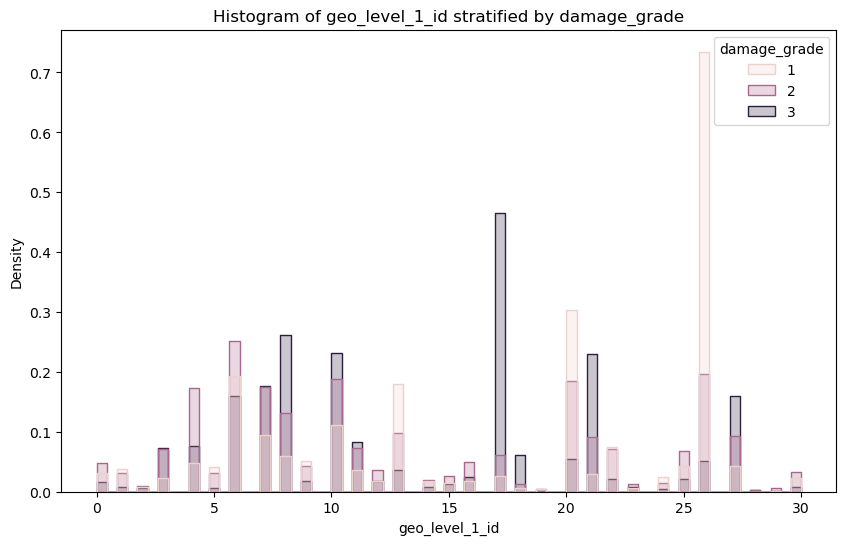

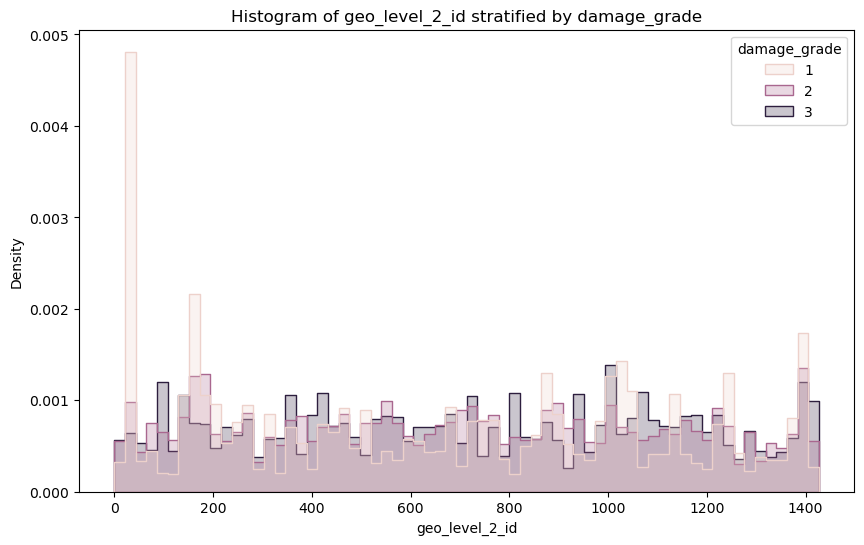

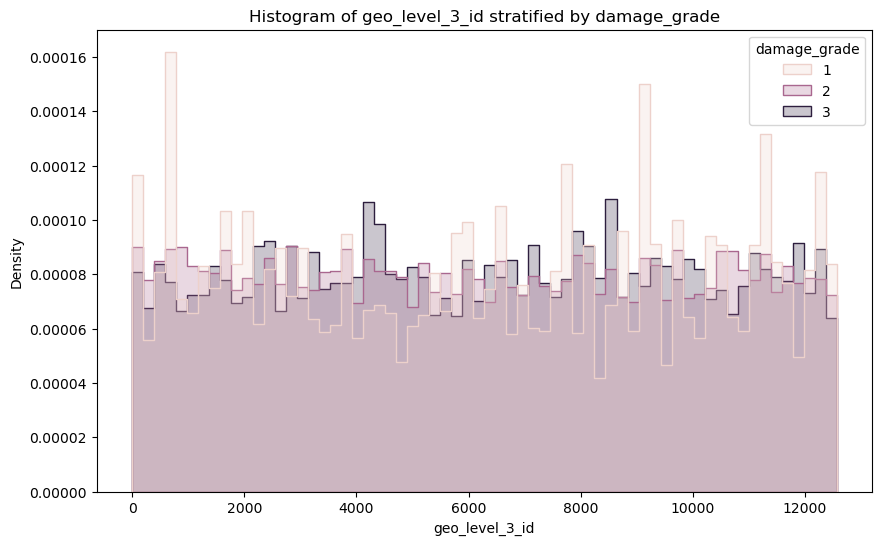

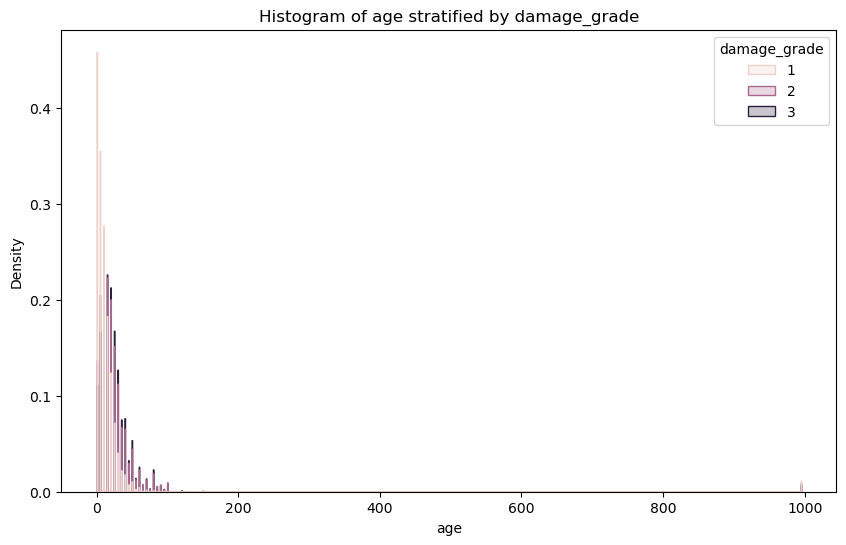

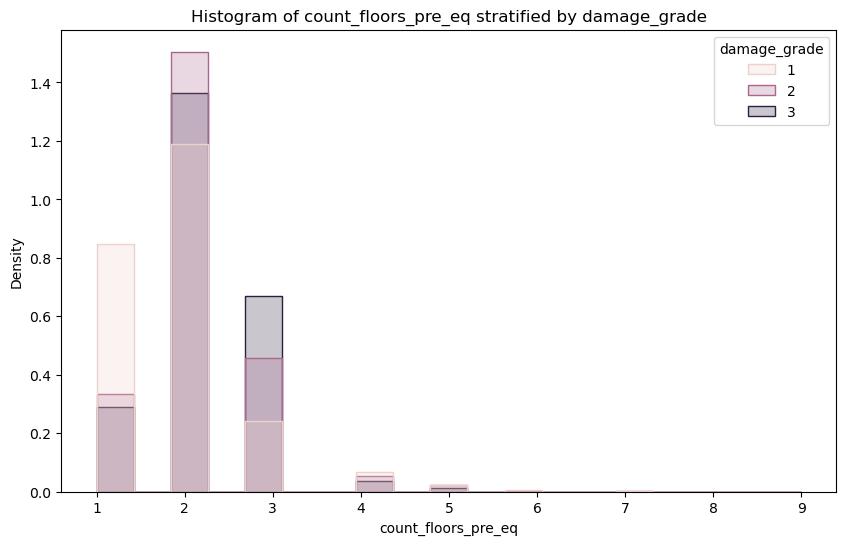

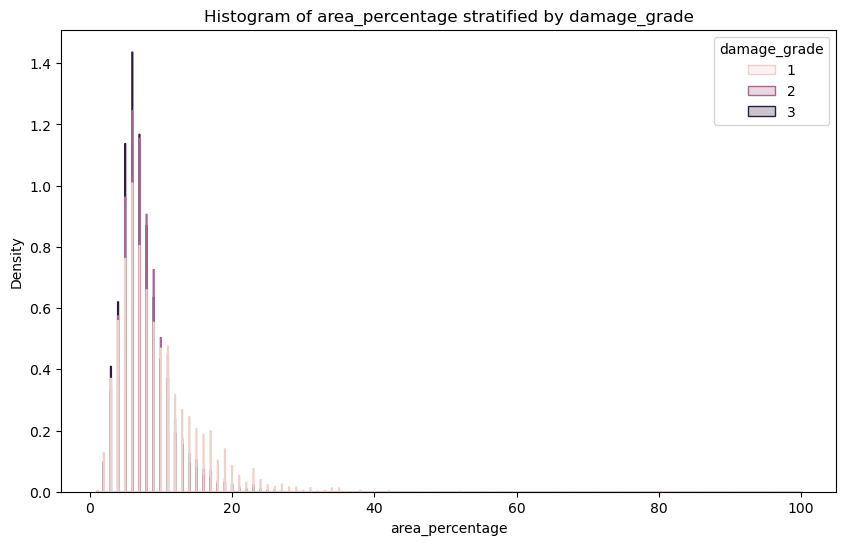

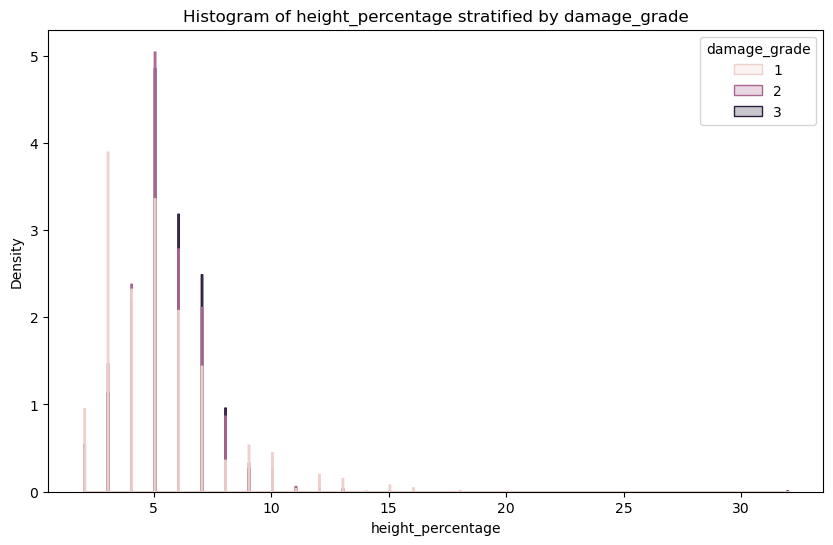

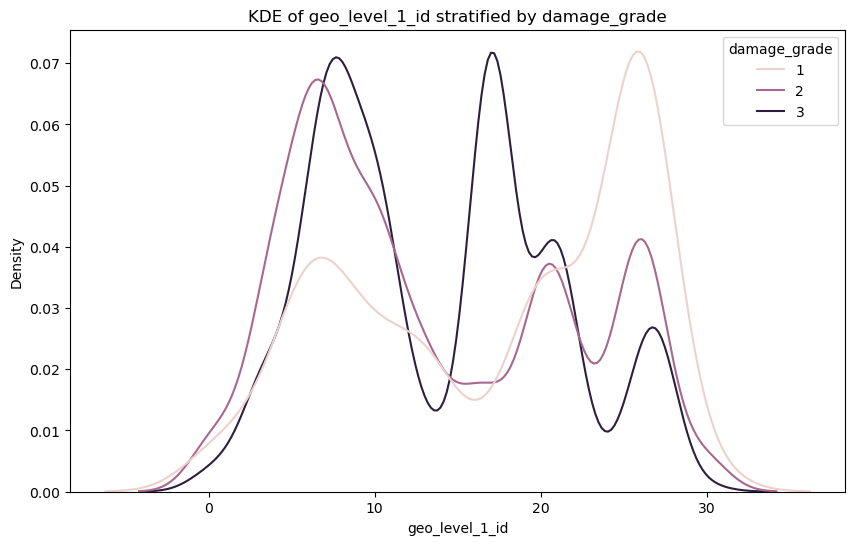

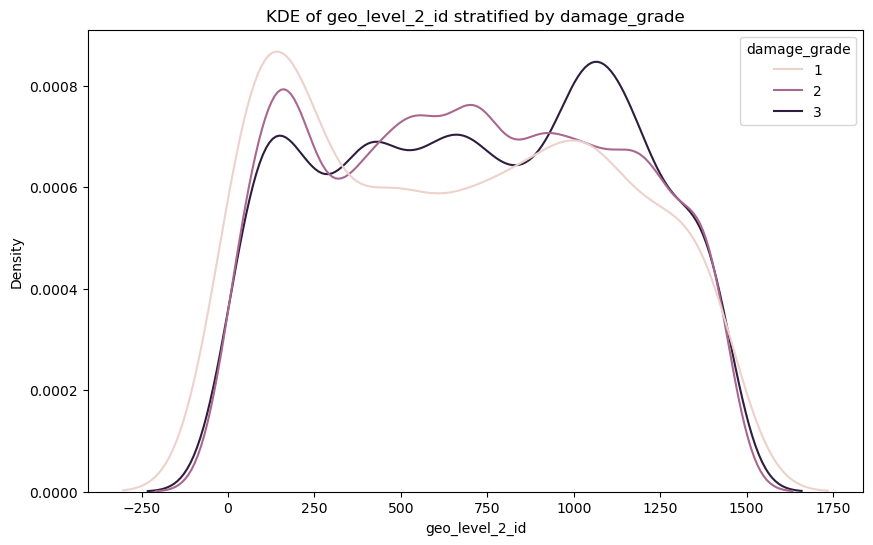

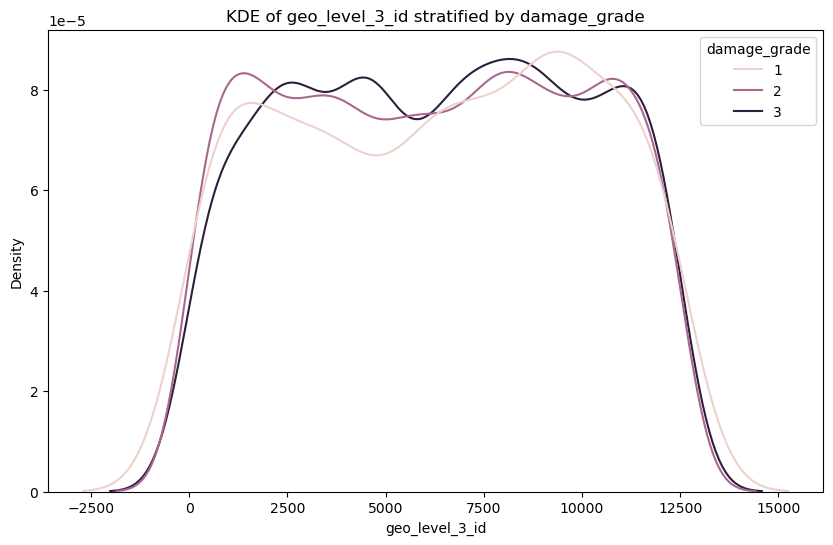

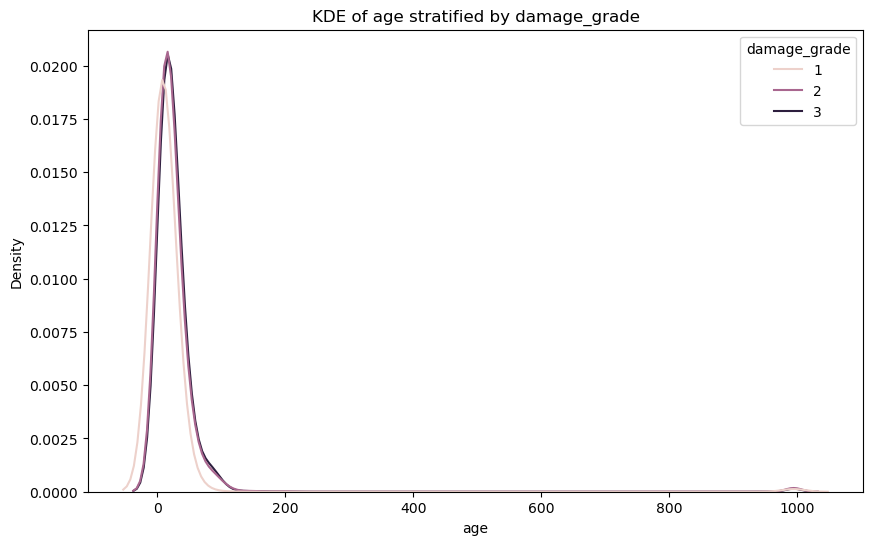

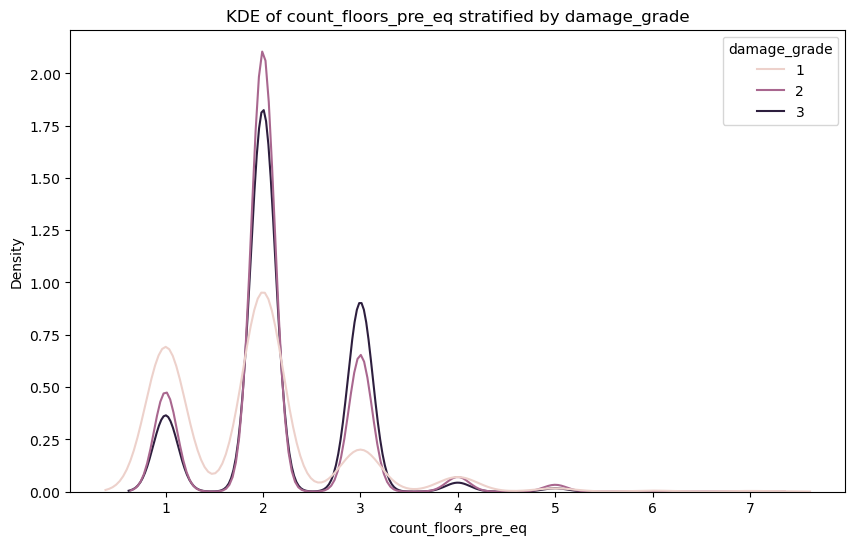

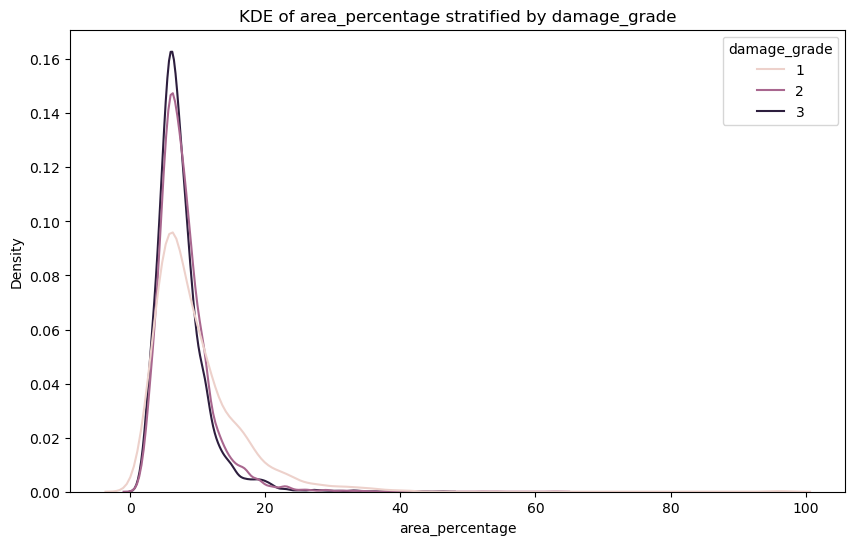

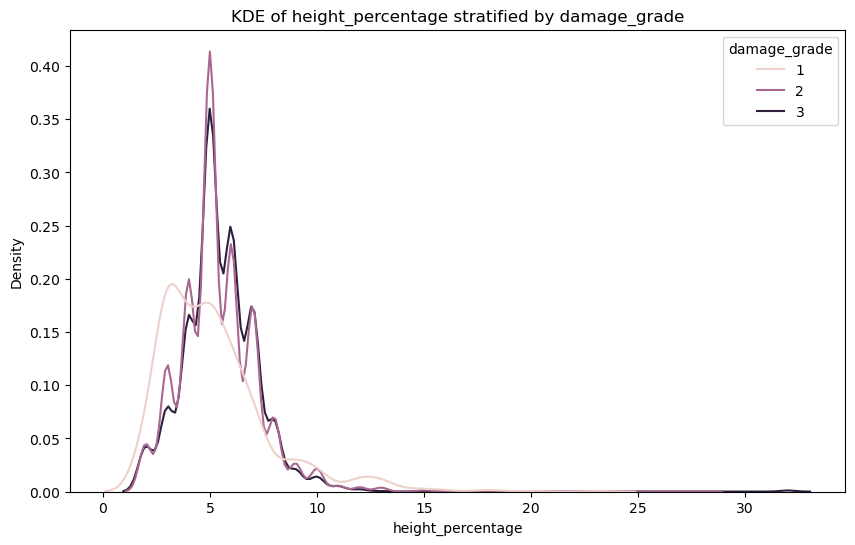

In [20]:
numerical_vars = ["geo_level_1_id","geo_level_2_id","geo_level_3_id","age","count_floors_pre_eq","area_percentage", "height_percentage"]
target = 'damage_grade'

def plot_hist_by_class(X, numerical_var, target):
    plt.figure(figsize=(10, 6))
    sns.histplot(
        data=df,
        x=numerical_var,
        hue=target,
        element="step",
        stat="density",   # normalize so imbalance doesn't distort
        common_norm=False # keep each class independent
    )
    plt.title(f"Histogram of {numerical_var} stratified by {target}")
    plt.show()


def plot_kde_by_class(X, numerical_var, target, sample_frac=0.1):
    # stratified sampling to keep class proportions
    df_sample = df.groupby(target).sample(frac=sample_frac, random_state=42)

    plt.figure(figsize=(10, 6))
    sns.kdeplot(
        data=df_sample,
        x=numerical_var,
        hue=target,
        common_norm=False,
        fill=False
    )
    plt.title(f"KDE of {numerical_var} stratified by {target}")
    plt.show()

for col in numerical_vars:
    plot_hist_by_class(X, col, target)

for col in numerical_vars:
    plot_kde_by_class(X, col, target, sample_frac=0.05)



In the age building histogram, it appears there are buildings close to 1000 years. Also other variables have skewed distributions

In [21]:
df["age"].unique()

array([ 30,  10,  25,   0,  15,  20,  45,  55,   5,  40,  80,  60,  35,
        70,  50,  65, 100,  75,  85, 190, 995, 105,  90, 120,  95, 110,
       115, 150, 200, 130, 125, 140, 155, 160, 175, 135, 145, 195, 180,
       165, 170, 185])

In [25]:
df["age"].value_counts().loc[995]
df["age"].value_counts().sort_index().tail()

age
185       1
190       3
195       2
200     106
995    1390
Name: count, dtype: int64

In [35]:
df["age"].value_counts().loc[995]

np.int64(1390)

It appears to be a placeholder for missing values or recording errors. Looking at the other variables, it does not look anything else is off 

In [36]:
df[df["age"] == 995]

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,...,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
386,435557,14,1120,3789,3,995,12,5,t,r,...,0,0,0,0,0,0,0,0,0,2
716,597626,26,39,1851,2,995,27,6,t,i,...,0,0,0,0,0,0,0,0,0,1
1235,7560,26,1132,9472,2,995,8,5,t,r,...,0,0,0,0,0,0,0,0,0,3
1398,797271,26,39,1851,2,995,14,6,t,u,...,0,0,0,0,0,0,0,0,0,1
1635,857371,24,628,10750,2,995,10,5,t,r,...,0,0,0,0,0,0,0,0,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
259758,160373,27,390,11020,3,995,6,8,n,r,...,0,0,0,0,0,0,0,0,0,2
259893,9269,24,628,11511,2,995,8,5,n,r,...,0,0,0,0,0,0,0,0,0,2
260093,34321,17,1393,5939,2,995,8,4,t,r,...,0,0,0,0,0,0,0,0,0,3
260542,156434,8,696,7863,2,995,8,8,t,r,...,0,0,0,0,0,0,0,0,0,3


In [37]:
df["age"] = df["age"].replace(995, np.nan)

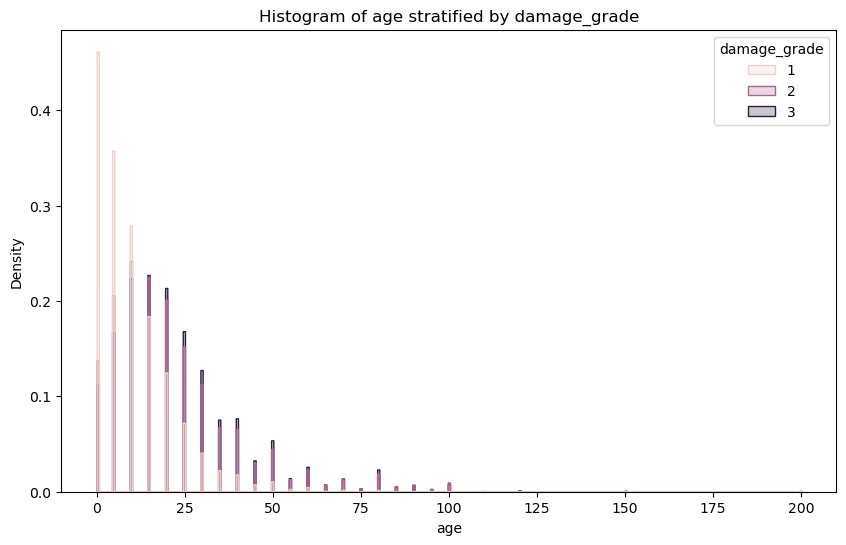

In [38]:
plot_hist_by_class(X, "age", target)

In [40]:
df["area_percentage"].unique()

array([  6,   8,   5,   9,   3,  13,   7,   4,  12,  16,  11,  27,  10,
        15,  14,  17,  21,  37,  19,   2,  28,  38,  56,   1,  20,  24,
        34,  26,  18,  31,  25,  23,  22,  32,  47,  36,  40,  29,  42,
        55,  35,  39, 100,  50,  51,  43,  30,  62,  85,  33,  45,  52,
        57,  49,  67,  66,  54,  75,  65,  58,  48,  64,  63,  46,  59,
        86,  78,  41,  44,  61,  70,  77,  73,  72,  53,  60,  84,  83,
        76,  96,  80,  90,  82,  69])

In [49]:
cat_var = ["land_surface_condition","foundation_type","roof_type","ground_floor_type","other_floor_type","position", "plan_configuration",
           "has_superstructure_adobe_mud", "has_superstructure_mud_mortar_stone", "has_superstructure_stone_flag", "has_superstructure_cement_mortar_stone", "has_superstructure_mud_mortar_brick",
           "has_superstructure_timber", "has_superstructure_bamboo", "has_superstructure_rc_non_engineered","has_superstructure_rc_engineered","has_superstructure_other",
           "legal_ownership_status","count_families","has_secondary_use"]

def plot_categorical_by_class(df, cat_var, target):
    plt.figure(figsize=(10, 6))
    prop_df = (
        df.groupby([target, cat_var])
          .size()
          .groupby(level=0)
          .apply(lambda x: x / x.sum())
          .reset_index(name="proportion")
    )

    sns.barplot(
        data=prop_df,
        x=cat_var,
        y="proportion",
        hue=target
    )
    plt.title(f"Proportion of {cat_var} categories stratified by {target}")
    plt.xticks(rotation=45)
    plt.show()


# plot_categorical_by_class(df, "land_surface_condition", "damage_grade")


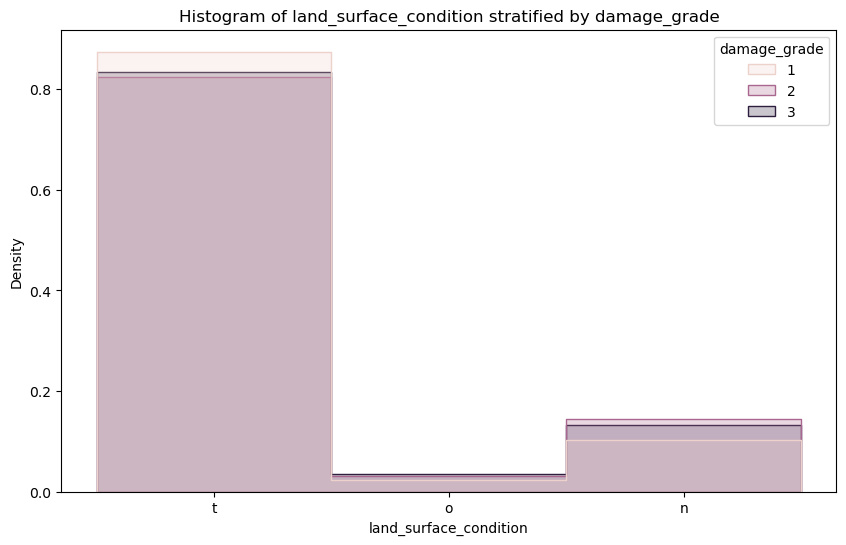

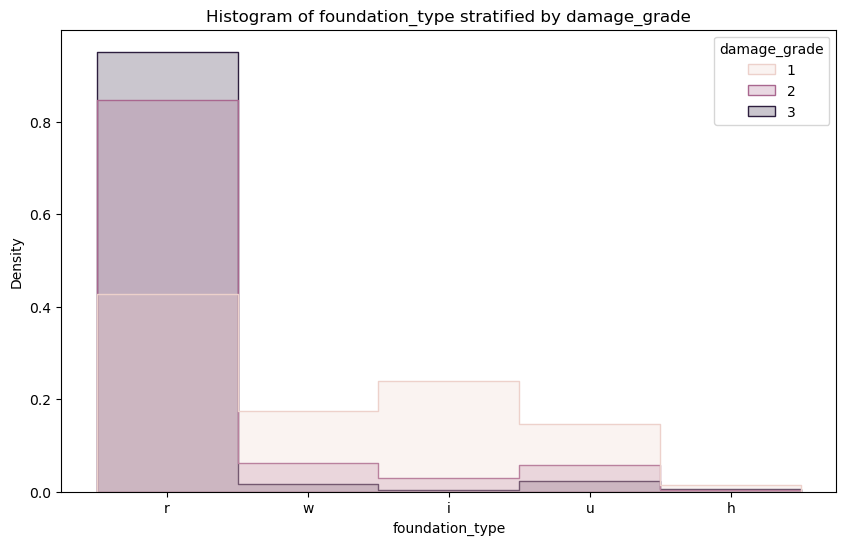

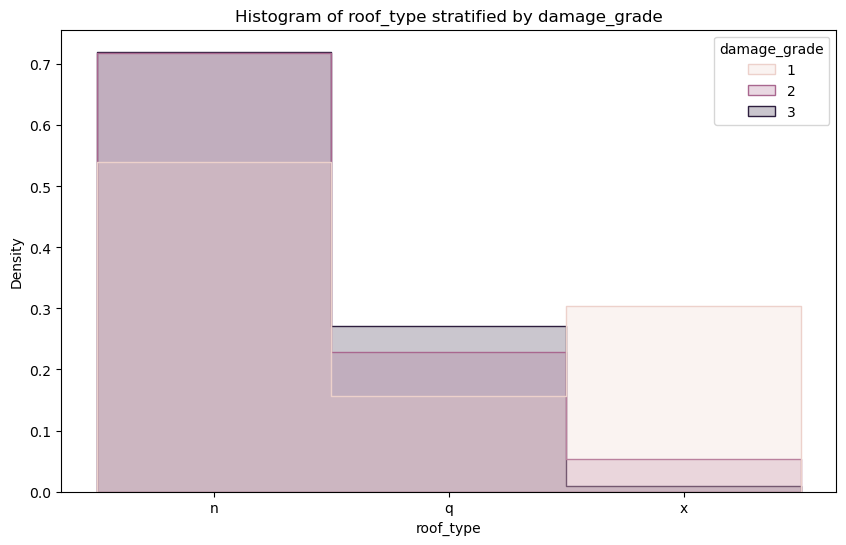

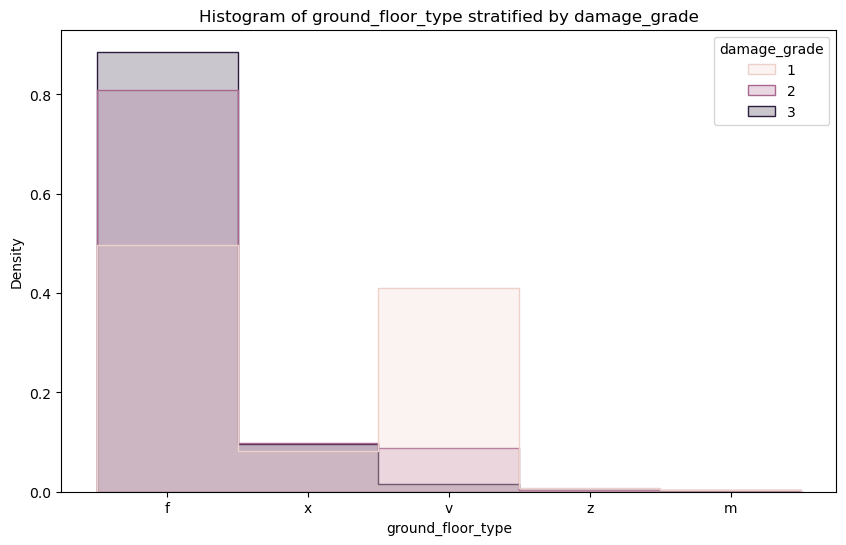

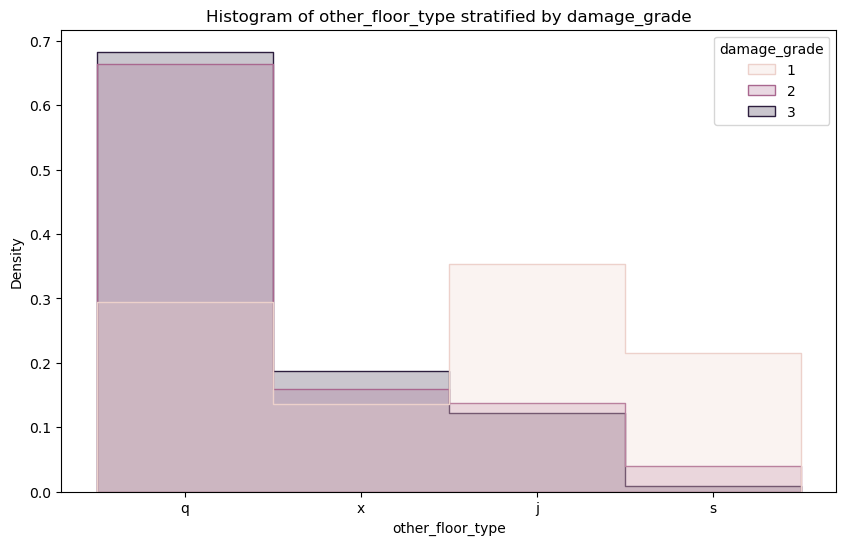

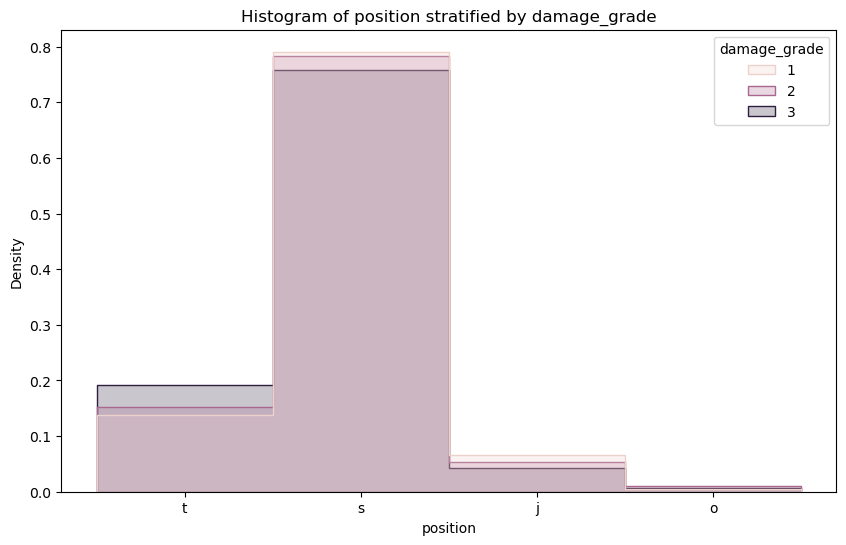

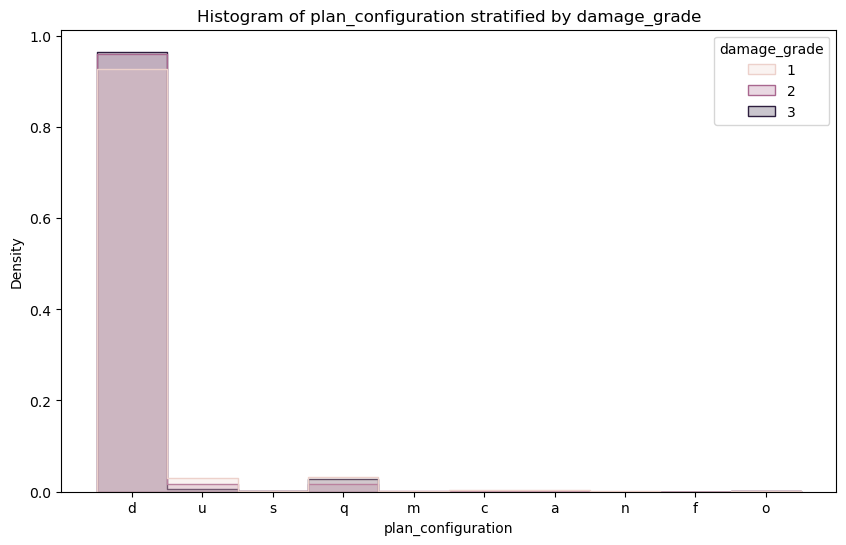

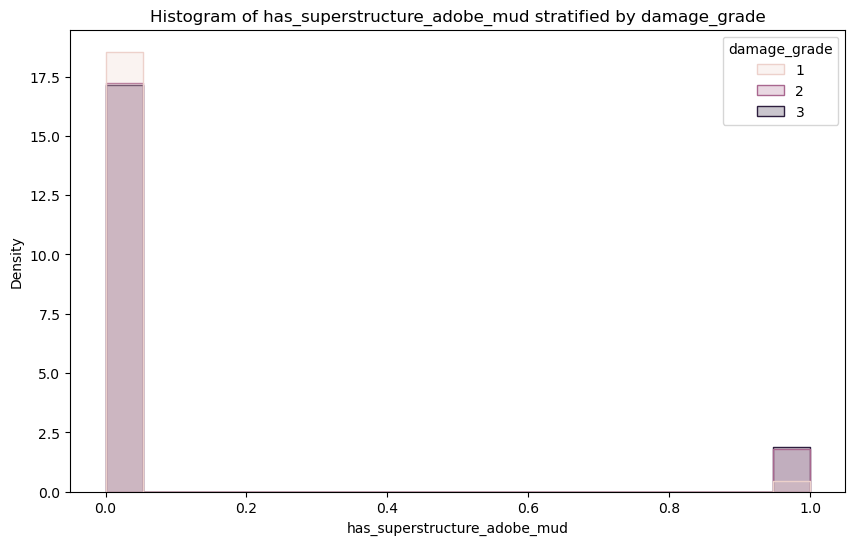

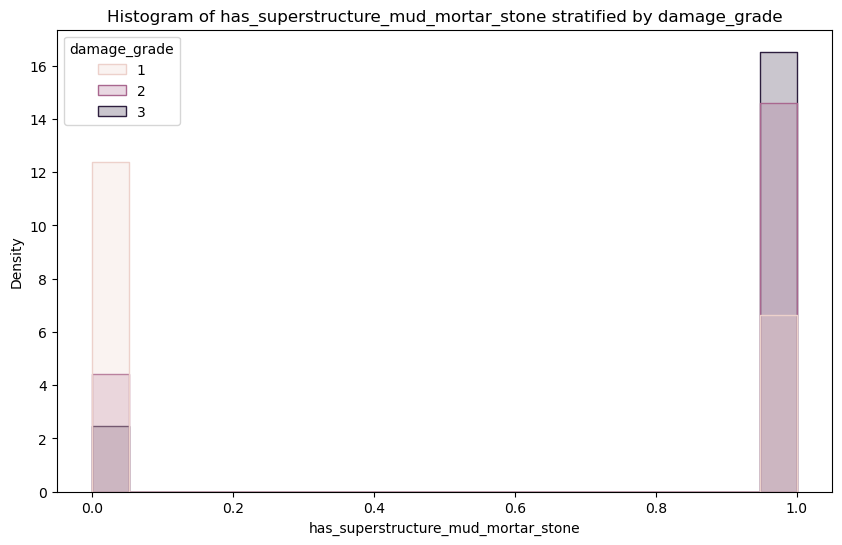

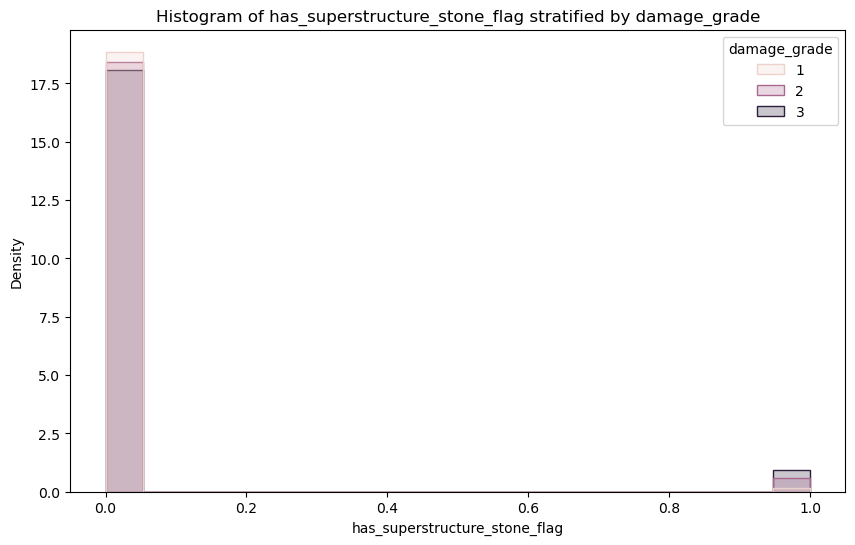

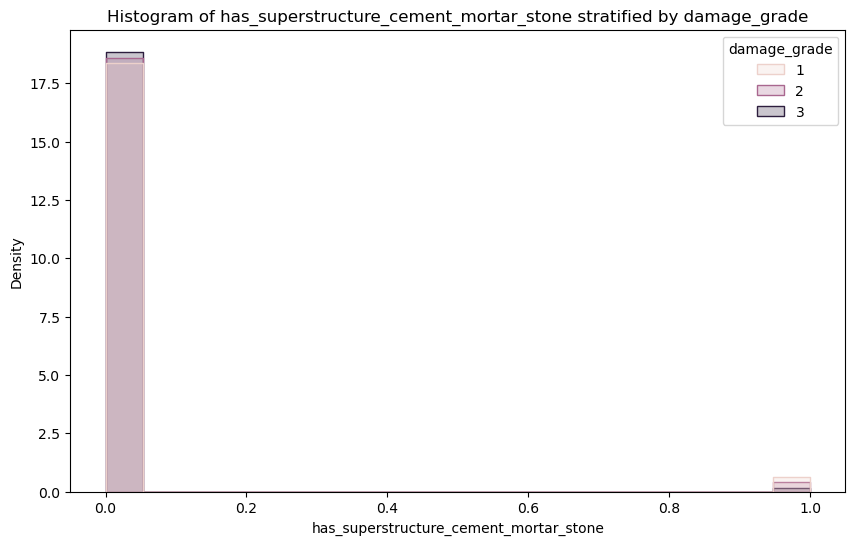

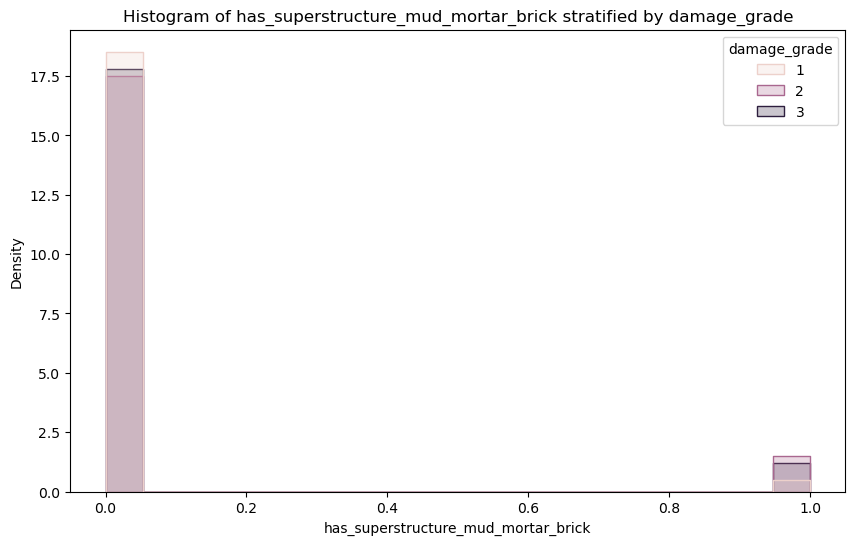

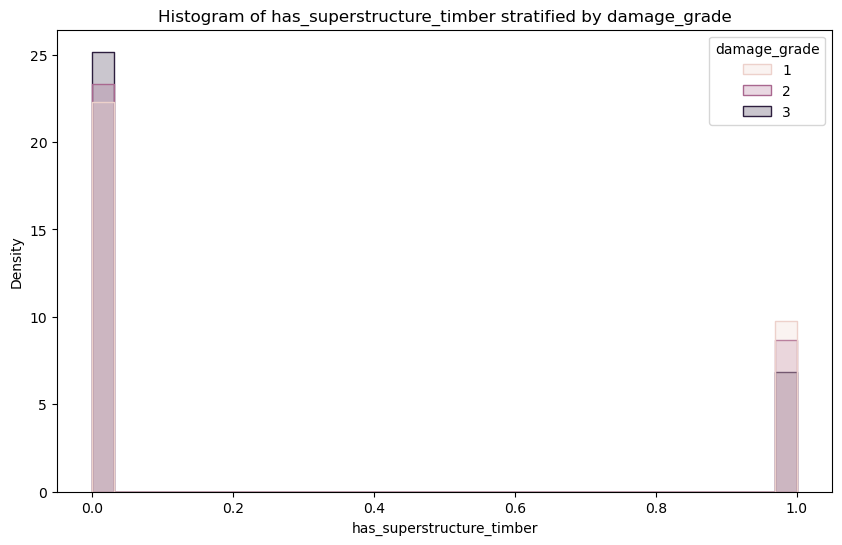

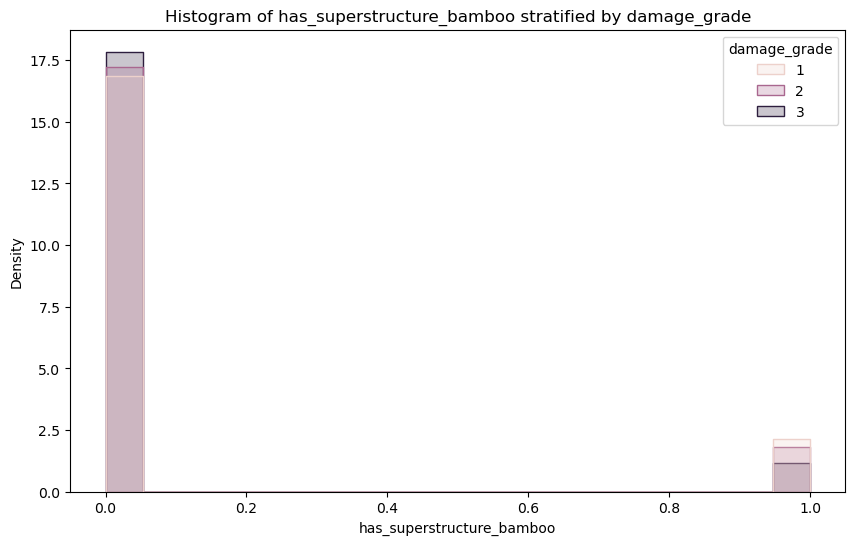

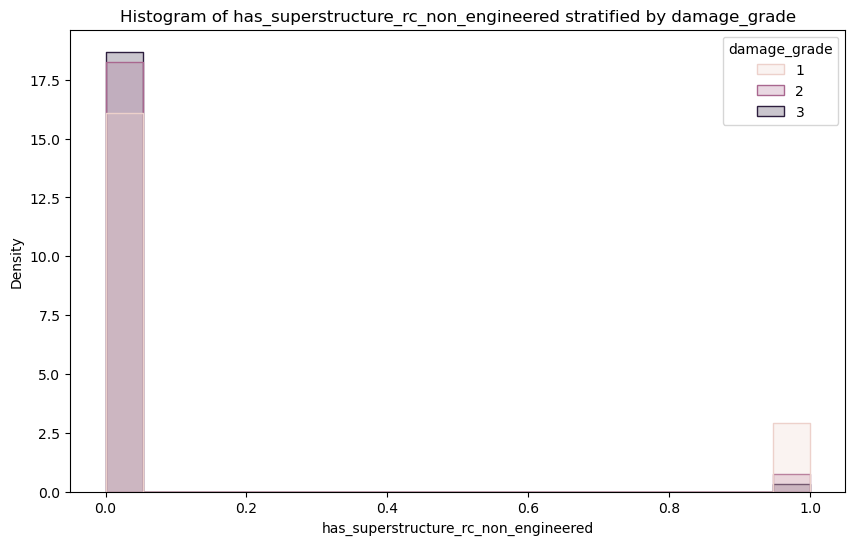

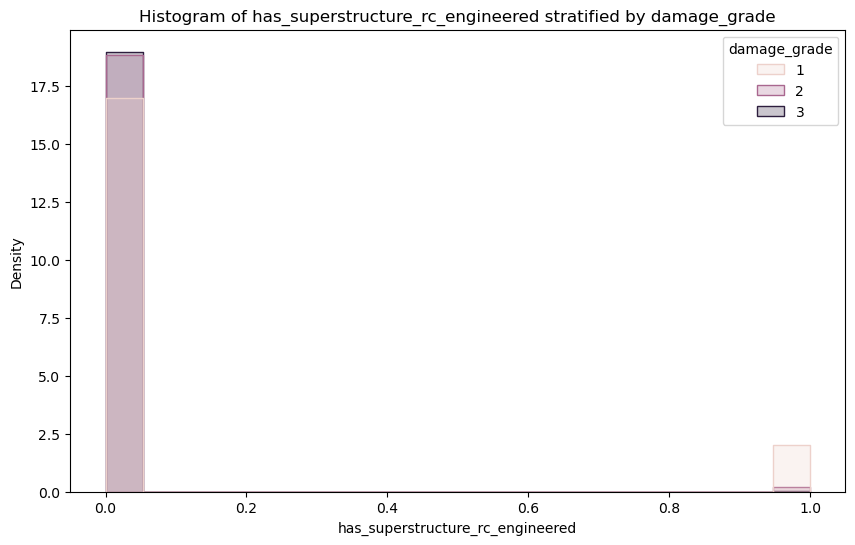

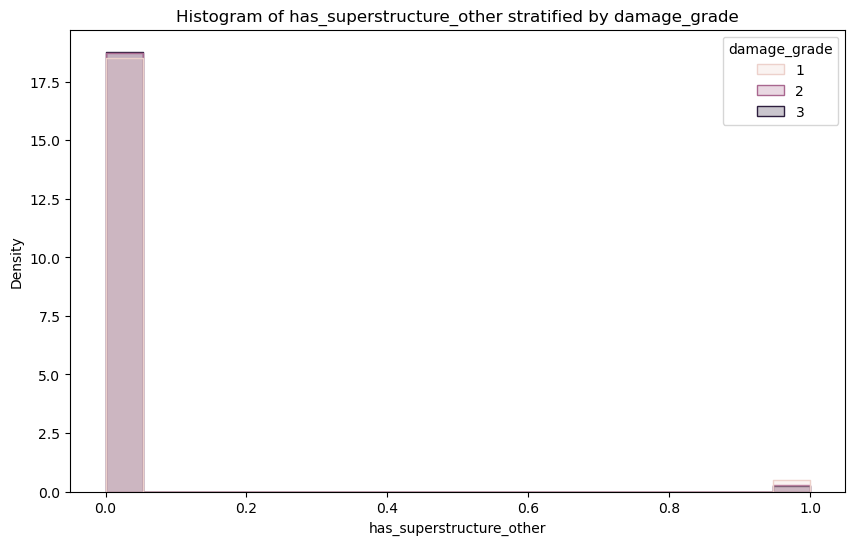

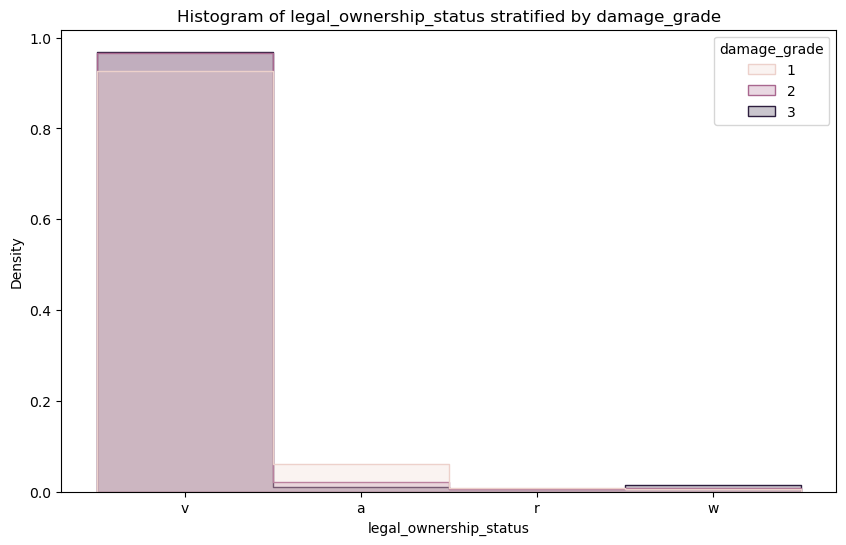

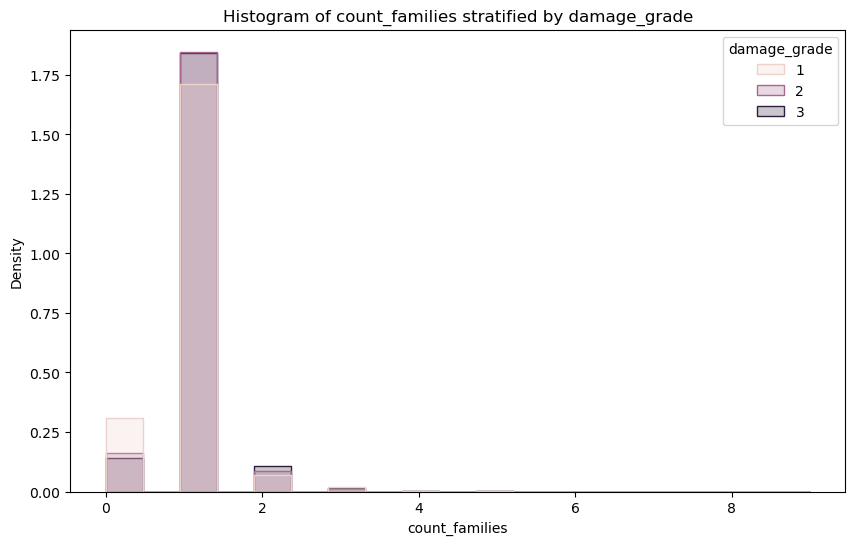

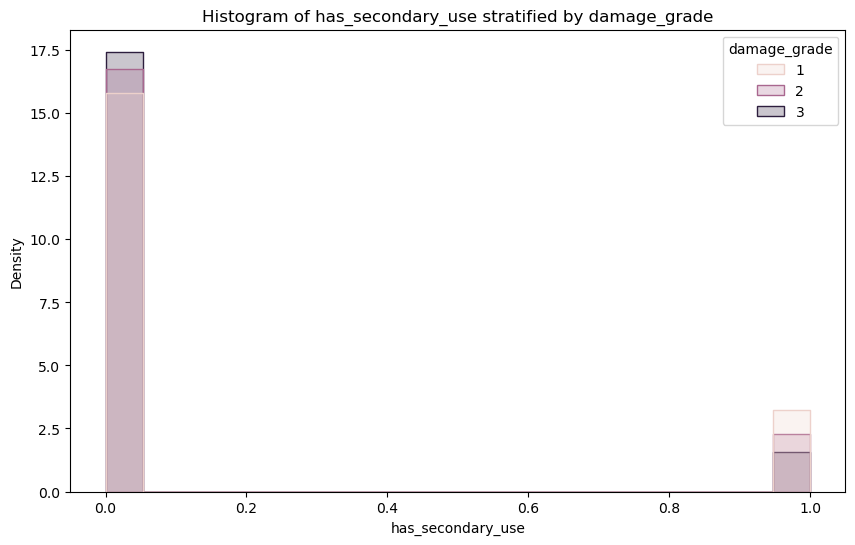

In [50]:
for col in cat_var:
    plot_hist_by_class(X, col, target)

Foundation type, roof type, floor types, has superstructure mud mortar, timber, bamboo, rc_non_engineered, rc_engeneered, secondary use --> might have an impact

Land surface, Position, plan configuration, superstructure stone flag, cement mortar, brick, other superstructure, ownership, family --> do not appear to have an impact

A PCA scatterplot can be used when many variables are present, and we want to see whether the three classes form clusters in lower‑dimensional space.

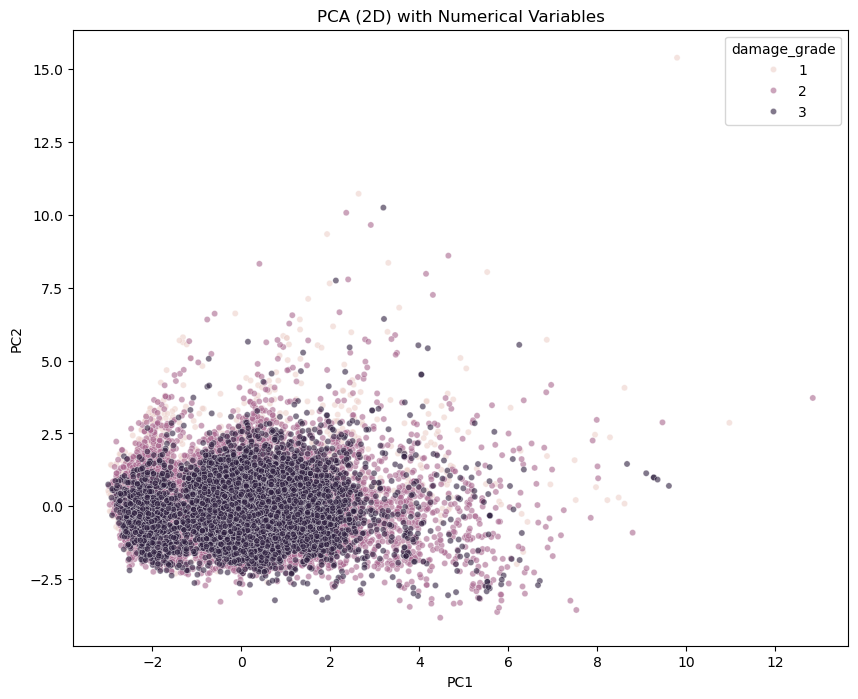

In [67]:
from sklearn.impute import SimpleImputer

#Function for PCA using only numerical features
def plot_pca_num(df, numerical_vars, target, sample_frac=0.1):

    # 1. Stratified sample for plotting (PCA can be fit on full data if desired)
    df_sample = df.groupby(target).sample(frac=sample_frac, random_state=42)

    X = df_sample[numerical_vars]
    y = df_sample[target]

       # 2. Preprocessing: impute → scale → encode
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]), numerical_vars),

            
        ]
    )


   # 3. PCA pipeline
    pca_pipeline = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("pca", PCA(n_components=2, random_state=42))
    ])

    # 4. Fit PCA and transform data
    X_pca = pca_pipeline.fit_transform(X)

    # 5. Build DataFrame for plotting
    pca_df = pd.DataFrame({
        "PC1": X_pca[:, 0],
        "PC2": X_pca[:, 1],
        target: y.values
    })

    # 6. Scatterplot
    plt.figure(figsize=(10, 8))
    sns.scatterplot(
        data=pca_df,
        x="PC1",
        y="PC2",
        hue=target,
        alpha=0.6,
        s=20
    )
    plt.title("PCA (2D) with Numerical Variables")
    plt.show()

    return pca_pipeline

pca_model = plot_pca_num(
    df,
    numerical_vars,
    target="damage_grade"
)





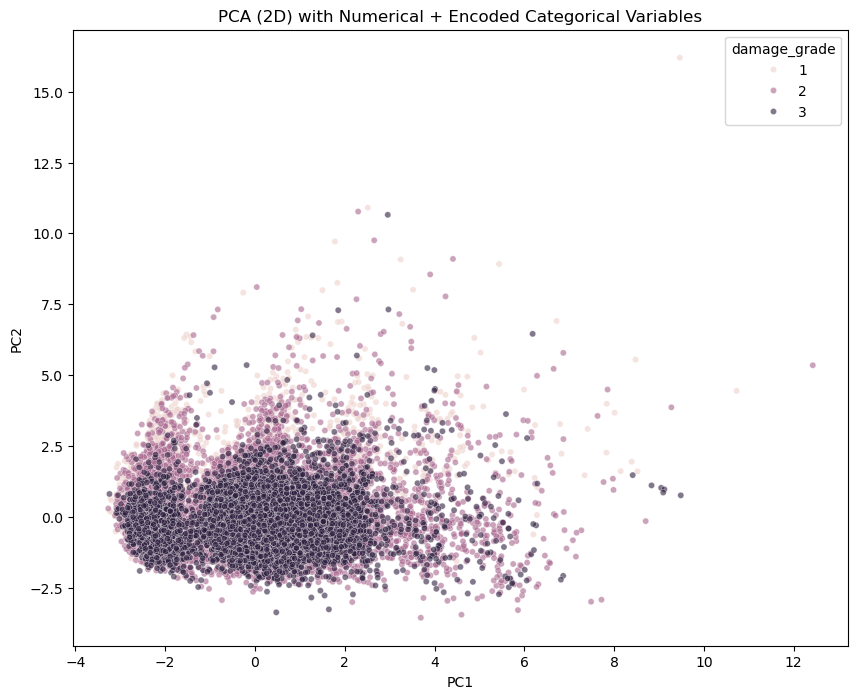

In [68]:
def plot_pca(df, numerical_vars, categorical_vars, target, sample_frac=0.1):

    # 1. Stratified sample for plotting (PCA can be fit on full data if desired)
    df_sample = df.groupby(target).sample(frac=sample_frac, random_state=42)

    X = df_sample[numerical_vars + categorical_vars]
    y = df_sample[target]

       # 2. Preprocessing: impute → scale → encode
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]), numerical_vars),

            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
            ]), categorical_vars)
        ]
    )

    # 3. PCA pipeline
    pca_pipeline = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("pca", PCA(n_components=2, random_state=42))
    ])

    # 4. Fit PCA and transform data
    X_pca = pca_pipeline.fit_transform(X)

    # 5. Build DataFrame for plotting
    pca_df = pd.DataFrame({
        "PC1": X_pca[:, 0],
        "PC2": X_pca[:, 1],
        target: y.values
    })

    # 6. Scatterplot
    plt.figure(figsize=(10, 8))
    sns.scatterplot(
        data=pca_df,
        x="PC1",
        y="PC2",
        hue=target,
        alpha=0.6,
        s=20
    )
    plt.title("PCA (2D) with Numerical + Encoded Categorical Variables")
    plt.show()

    return pca_pipeline

pca_model = plot_pca(
    df,
    numerical_vars,
    cat_var,
    target="damage_grade"
)


Using every feature considered above, there is no clear separation into cluster between the three damage categories. Selecting specific categories:

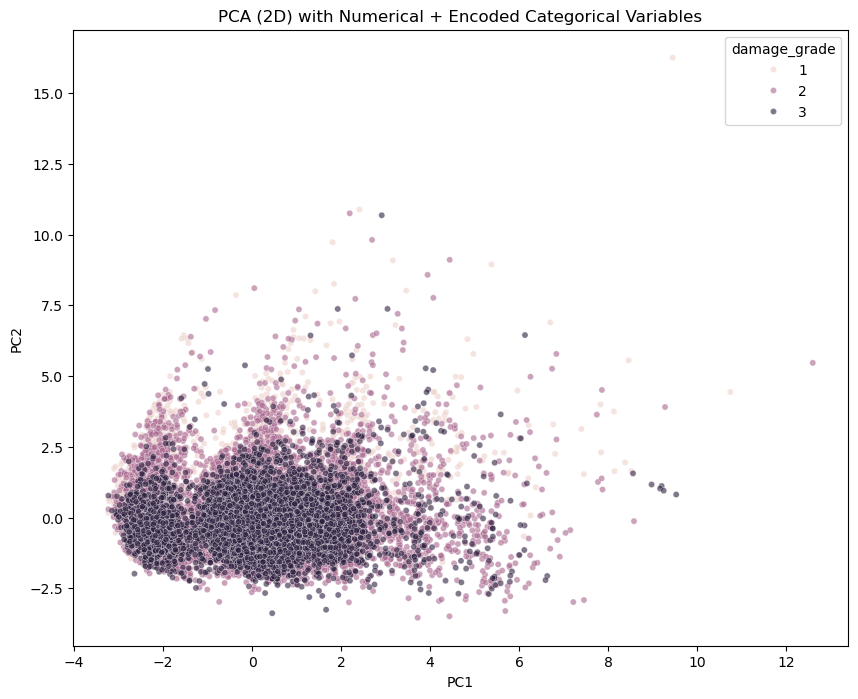

In [74]:
cat_var1 = ["foundation_type","roof_type","ground_floor_type","other_floor_type", "has_superstructure_mud_mortar_stone",
           "has_superstructure_timber", "has_superstructure_bamboo", "has_superstructure_rc_non_engineered","has_superstructure_rc_engineered","has_secondary_use"]

numerical_vars1 = ["geo_level_1_id","geo_level_2_id","geo_level_3_id","age","count_floors_pre_eq","area_percentage", "height_percentage"]


pca_model = plot_pca(
    df,
    numerical_vars1,
    cat_var1,
    target="damage_grade"
)